# Fine-Tuning DziriBERT for Fake News Classification in Algerian Dialect

This notebook demonstrates a **two-phase training strategy** for fine-tuning DziriBERT on fake news classification in Algerian dialect (Darja).

## Training Strategy

**Phase 1: Partial Fine-Tuning**
- Freeze most of the encoder layers
- Train only the classification head + last 2 transformer layers
- Learning rate: 1e-4 (0.0001)
- Epochs: 10

**Phase 2: Full Fine-Tuning**
- Unfreeze all layers
- Continue training with reduced learning rate
- Learning rate: 1e-6 (0.000001)
- Epochs: 5

## Dataset
- 4-class classification: {0, 1, 2, 3}
- Text in Algerian dialect (Darja)
- CSV format with 'text' and 'label' columns

## 1. Imports & Setup

In [1]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.8/899.8 MB 30.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 31.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 23.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 45.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 30.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 38.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 41.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 33.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 33.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 41.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.4/800.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.9 MB/s eta 0:00:00


In [3]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW

# Hugging Face
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Scikit-learn for metrics and splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Set random seeds for reproducibility
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA H100 NVL MIG 1g.24gb


In [4]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [5]:
# Configuration
class Config:
    # Model
    MODEL_NAME = "alger-ia/dziribert"
    NUM_LABELS = 4
    MAX_LENGTH = 256
    
    # Dataset
    DATA_PATH = "new_data.csv"  # Update with your actual path
    TRAIN_SIZE = 0.8 # I will edit this to add a separate test set 
    
    # Phase 1: Partial fine-tuning
    PHASE1_EPOCHS = 10
    PHASE1_LR = 0.0001
    PHASE1_BATCH_SIZE = 16
    
    # Phase 2: Full fine-tuning
    PHASE2_EPOCHS = 5
    PHASE2_LR = 0.000001
    PHASE2_BATCH_SIZE = 16
    
    # Training
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    GRADIENT_ACCUMULATION_STEPS = 1
    MAX_GRAD_NORM = 1.0
    
    # Early stopping
    EARLY_STOPPING_PATIENCE = 5  # Stop if no improvement for 5 epochs

    # Paths
    OUTPUT_DIR = "./outputs"
    MODEL_SAVE_PATH = "./saved_model"
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()
print(f"Training device: {config.DEVICE}")
print(f"Model: {config.MODEL_NAME}")

Training device: cuda
Model: alger-ia/dziribert


## 2. Load and Preprocess Dataset

Loading dataset...
Dataset shape: (7329, 5)

First few rows:
    source        date  label category  \
0  twitter  2025-11-16      3   nation   
1  twitter  2025-11-16      0    monde   
2  twitter  2025-11-16      1  societe   
3  twitter  2025-11-16      2   nation   
4  twitter  2025-11-16      0    monde   

                                                text  
0  نفس العقلية اللي عند جماعة الحظيرة في الدزاير،...  
1  خبر عاجل هادو هما ليكيبيات اللي كاليفياو لكاس ...  
2  هادي تخصك إذا راك مقلق على الفيزا تاعك من غير ...  
3  ياو الفايدة كامل راهي في الشرق، ماشي الغرب الل...  
4  رسمي وعاجل هادو هما المنتخبات اللي تآهلو لكاس ...  

Missing values:
source         0
date        2575
label          0
category       0
text           0
dtype: int64

Class distribution:
label
0    4397
1     796
2     127
3    2009
Name: count, dtype: int64


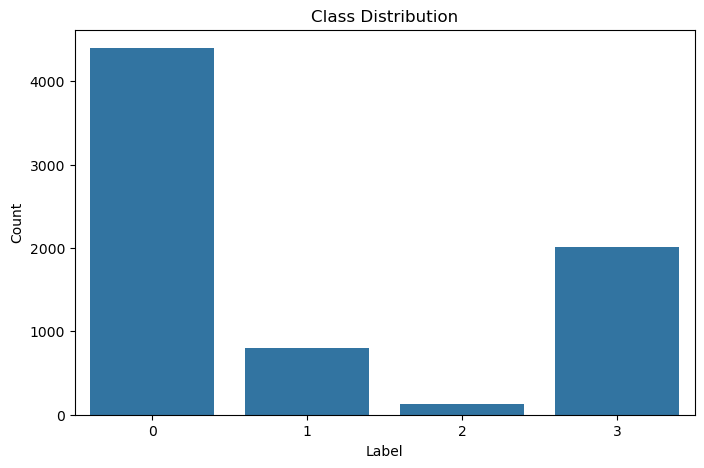

In [6]:
# Load dataset
print("Loading dataset...")

df = pd.read_csv(config.DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# Class distribution
print(f"\nClass distribution:")
print(df['label'].value_counts().sort_index())

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [7]:
# ============================================================================
# Clean dataset: Remove emojis and special characters
# ============================================================================
import re

# emojis were already removed in the preprocessing step, this is just to double check
def remove_emojis(text):
    """
    Remove emojis and other pictographic characters from text
    """
    # Emoji pattern - covers most emoji ranges
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002500-\U00002BEF"  # chinese char
        "\U00002702-\U000027B0"  # Dingbats
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001f926-\U0001f937"  # supplemental symbols
        "\U00010000-\U0010ffff"  # extended characters
        "\u2640-\u2642" 
        "\u2600-\u2B55"
        "\u200d"
        "\u23cf"
        "\u23e9"
        "\u231a"
        "\ufe0f"  # dingbats
        "\u3030"
        "]+",
        flags=re.UNICODE
    )
    
    return emoji_pattern.sub(r'', text)

# additional basic cleaning
def clean_text(text):
    """
    Comprehensive text cleaning:
    - Remove emojis
    - Remove extra whitespace
    - Remove zero-width characters
    """
    text = str(text)
    
    # Remove emojis
    text = remove_emojis(text)
    
    # Remove zero-width characters and other invisible Unicode
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
    
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    return text

print("\n" + "="*80)
print("CLEANING TEXT DATA - REMOVING EMOJIS & SPECIAL CHARACTERS")
print("="*80)

# Count emojis before cleaning
emoji_pattern = re.compile(
    "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+",
    flags=re.UNICODE
)

texts_with_emojis = 0
for text in df['text']:
    if emoji_pattern.search(str(text)):
        texts_with_emojis += 1

print(f"\nBefore cleaning:")
print(f"  Total texts: {len(df)}")
print(f"  Texts with emojis: {texts_with_emojis} ({texts_with_emojis/len(df)*100:.2f}%)")

# Show examples before cleaning
if texts_with_emojis > 0:
    print(f"\n{'='*80}")
    print("EXAMPLES BEFORE CLEANING")
    print(f"{'='*80}")
    
    examples_shown = 0
    for idx, row in df.iterrows():
        text = str(row['text'])
        if emoji_pattern.search(text) and examples_shown < 3:
            print(f"\nExample {examples_shown + 1}:")
            print(f"  Original: {text[:150]}...")
            examples_shown += 1

# Clean all texts
print(f"\nCleaning all texts...")
df['text'] = df['text'].apply(clean_text)

# Remove empty texts after cleaning
original_size = len(df)
df = df[df['text'].str.len() > 0]
removed_empty = original_size - len(df)

print(f"\nAfter cleaning:")
print(f"  Total texts: {len(df)}")
print(f"  Empty texts removed: {removed_empty}")

# Show examples after cleaning
if texts_with_emojis > 0:
    print(f"\n{'='*80}")
    print("EXAMPLES AFTER CLEANING")
    print(f"{'='*80}")
    
    examples_shown = 0
    for idx in range(min(3, len(df))):
        text = df.iloc[idx]['text']
        print(f"\nExample {examples_shown + 1}:")
        print(f"  Cleaned: {text[:150]}...")
        examples_shown += 1

# Check text length statistics
text_lengths = df['text'].str.len()
print(f"\nText length statistics (characters):")
print(f"  Min: {text_lengths.min()}")
print(f"  Max: {text_lengths.max()}")
print(f"  Mean: {text_lengths.mean():.1f}")
print(f"  Median: {text_lengths.median():.1f}")

print(f"\nText cleaning complete!")
print(f"{'='*80}\n")


CLEANING TEXT DATA - REMOVING EMOJIS & SPECIAL CHARACTERS

Before cleaning:
  Total texts: 7329
  Texts with emojis: 0 (0.00%)

Cleaning all texts...

After cleaning:
  Total texts: 7329
  Empty texts removed: 0

Text length statistics (characters):
  Min: 1
  Max: 10899
  Mean: 215.9
  Median: 84.0

Text cleaning complete!



In [8]:
# Split into train+val and test sets
### Keep a separate test set for final evaluation ###
print("Splitting dataset...")

# First split: separate test set (10% of data)
temp_df, test_df = train_test_split(
    df,
    test_size=0.10,  # 10% for test set
    random_state=42,
    stratify=df['label']  # Maintain class distribution
)

print(f"Total dataset size: {len(df)}")
print(f"Test set size: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
print(f"Remaining for train+val: {len(temp_df)} ({len(temp_df)/len(df)*100:.1f}%)")

# Second split: train and validation from remaining data
# config.TRAIN_SIZE = 0.8 means 80% of temp_df for training
train_df, val_df = train_test_split(
    temp_df,
    train_size=config.TRAIN_SIZE,
    random_state=42,
    stratify=temp_df['label']  # Maintain class distribution
)

print(f"\nFinal split:")
print(f"  Train set: {len(train_df)} ({len(train_df)/len(df)*100:.1f}% of total)")
print(f"  Validation set: {len(val_df)} ({len(val_df)/len(df)*100:.1f}% of total)")
print(f"  Test set: {len(test_df)} ({len(test_df)/len(df)*100:.1f}% of total)")

# Verify class distribution in all splits
print(f"\nTrain set class distribution:")
print(train_df['label'].value_counts().sort_index())

print(f"\nValidation set class distribution:")
print(val_df['label'].value_counts().sort_index())

print(f"\nTest set class distribution:")
print(test_df['label'].value_counts().sort_index())

print(f"\n{'='*80}")
print("NOTE: Test set will be kept aside until final inference (Section 10)")
print(f"{'='*80}")

Splitting dataset...
Total dataset size: 7329
Test set size: 733 (10.0%)
Remaining for train+val: 6596 (90.0%)

Final split:
  Train set: 5276 (72.0% of total)
  Validation set: 1320 (18.0% of total)
  Test set: 733 (10.0% of total)

Train set class distribution:
label
0    3165
1     574
2      91
3    1446
Name: count, dtype: int64

Validation set class distribution:
label
0    792
1    143
2     23
3    362
Name: count, dtype: int64

Test set class distribution:
label
0    440
1     79
2     13
3    201
Name: count, dtype: int64

NOTE: Test set will be kept aside until final inference (Section 10)


In [9]:
# ============================================================================
# Compute class weights for imbalanced dataset
# ============================================================================
# Class weights are inversely proportional to class frequency
# This makes the loss function penalize errors on minority classes more heavily

print("\n" + "="*80)
print("COMPUTING CLASS WEIGHTS FOR IMBALANCED DATA")
print("="*80)

# Compute class counts from TRAINING set only
train_class_counts = train_df['label'].value_counts().sort_index()
print(f"\nTraining set class counts:")
for class_idx, count in train_class_counts.items():
    print(f"  Class {class_idx}: {count} samples")

# Compute normalized class weights (inverse frequency)
total_samples = len(train_df)
class_weights = torch.zeros(config.NUM_LABELS)

for class_idx in range(config.NUM_LABELS):
    count = train_class_counts.get(class_idx, 0)
    if count > 0:
        # Weight = total_samples / (num_classes * class_count)
        class_weights[class_idx] = total_samples / (config.NUM_LABELS * count)
    else:
        class_weights[class_idx] = 1.0

print(f"\nClass weights (normalized):")
for class_idx, weight in enumerate(class_weights):
    print(f"  Class {class_idx}: {weight:.4f}")

# ============================================================================
# Compute sample weights for WeightedRandomSampler
# ============================================================================
# Each sample is weighted by its class weight
# This ensures minority classes are sampled more frequently during training

sample_weights = np.zeros(len(train_df))
for idx, label in enumerate(train_df['label'].values):
    sample_weights[idx] = class_weights[label].item()

print(f"\nSample weights computed for {len(sample_weights)} training samples")
print(f"Sample weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")
print("="*80)


COMPUTING CLASS WEIGHTS FOR IMBALANCED DATA

Training set class counts:
  Class 0: 3165 samples
  Class 1: 574 samples
  Class 2: 91 samples
  Class 3: 1446 samples

Class weights (normalized):
  Class 0: 0.4167
  Class 1: 2.2979
  Class 2: 14.4945
  Class 3: 0.9122

Sample weights computed for 5276 training samples
Sample weight range: [0.4167, 14.4945]


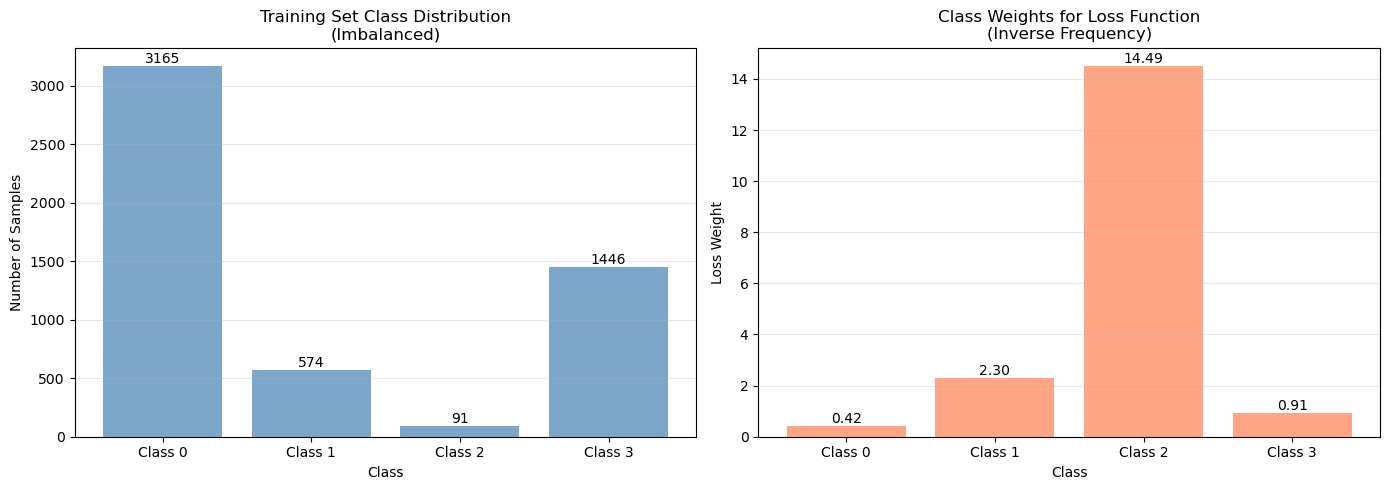


Interpretation:
   - Left plot: Shows original class imbalance in training data
   - Right plot: Shows corresponding weights applied in loss function
   - Minority classes get higher weights to balance their impact on training


In [10]:
# Visualize class weights impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class distribution
class_counts = train_class_counts.values
class_labels = [f'Class {i}' for i in range(config.NUM_LABELS)]

axes[0].bar(class_labels, class_counts, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Training Set Class Distribution\n(Imbalanced)')
axes[0].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (label, count) in enumerate(zip(class_labels, class_counts)):
    axes[0].text(i, count, str(count), ha='center', va='bottom')

# Plot 2: Class weights
weights = class_weights.numpy()
axes[1].bar(class_labels, weights, color='coral', alpha=0.7)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Loss Weight')
axes[1].set_title('Class Weights for Loss Function\n(Inverse Frequency)')
axes[1].grid(True, alpha=0.3, axis='y')

# Add weight labels on bars
for i, (label, weight) in enumerate(zip(class_labels, weights)):
    axes[1].text(i, weight, f'{weight:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("   - Left plot: Shows original class imbalance in training data")
print("   - Right plot: Shows corresponding weights applied in loss function")
print("   - Minority classes get higher weights to balance their impact on training")

## 3. Tokenization

In [11]:
# Load tokenizer
print(f"Loading tokenizer: {config.MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

print(f"Tokenizer loaded successfully")
print(f"Vocabulary size: {tokenizer.vocab_size}")

# Test tokenization
sample_text = train_df.iloc[0]['text']
encoded = tokenizer(
    sample_text,
    max_length=config.MAX_LENGTH,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)

print(f"\nSample tokenization:")
print(f"Text: {sample_text}")
print(f"Input IDs shape: {encoded['input_ids'].shape}")
print(f"Attention mask shape: {encoded['attention_mask'].shape}")

Loading tokenizer: alger-ia/dziribert


tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully
Vocabulary size: 50000

Sample tokenization:
Text: بنة الصابليت تلاقوها متوفرة بذوق الشوكولا، الفراولة، والتين. تناسب قاع الأذواق وحتى اللي ما يحبوش السكر بزاف. سايدة بلاش أنت.
Input IDs shape: torch.Size([1, 256])
Attention mask shape: torch.Size([1, 256])



TEXT LENGTH ANALYSIS

Analyzing 1000 samples from training set...


Tokenizing texts:   0%|          | 0/1000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (731 > 512). Running this sequence through the model will result in indexing errors



Statistic            Value     
------------------------------
Min length:          4         
Max length:          2694      
Mean length:         60.13     
Median length:       23.00     
Std deviation:       133.20    

Percentile           Length     % Covered      
---------------------------------------------
50th percentile:       23         97.00          % ✓
75th percentile:       47         97.00          % ✓
90th percentile:       149        97.00          % ✓
95th percentile:       188        97.00          % ✓
99th percentile:       592        97.00          % ⚠️
100th percentile:       2694       97.00          % ⚠️

CURRENT MAX_LENGTH = 256
✓ Covers 97.00% of texts without truncation
⚠️  30 texts (3.00%) will be truncated
   Average length of truncated texts: 602 tokens
   Average tokens lost per truncated text: 346


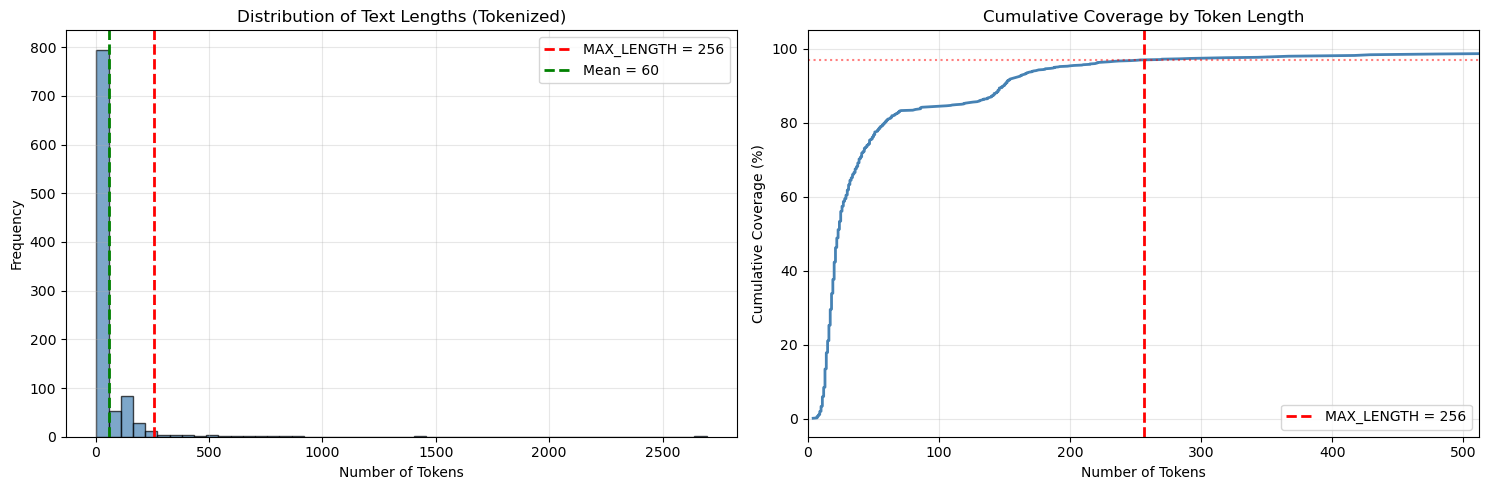


RECOMMENDATIONS
✓ MAX_LENGTH is good! Covers 95%+ of your data.
  Consider increasing to 592 to cover 99%

💡 Memory Trade-off:
  Current MAX_LENGTH=256: ~4.1K tokens/batch




In [12]:
# ============================================================================
# Analyze text lengths to validate MAX_LENGTH setting
# ============================================================================
print("\n" + "="*80)
print("TEXT LENGTH ANALYSIS")
print("="*80)

# Tokenize all texts and measure lengths
def analyze_text_lengths(df, tokenizer, sample_size=None):
    """
    Analyze the distribution of tokenized text lengths
    """
    texts = df['text'].values
    if sample_size and sample_size < len(texts):
        texts = np.random.choice(texts, sample_size, replace=False)
    
    lengths = []
    for text in tqdm(texts, desc="Tokenizing texts"):
        tokens = tokenizer.encode(str(text), add_special_tokens=True)
        lengths.append(len(tokens))
    
    return np.array(lengths)

# Analyze training set (use sample if dataset is very large)
sample_size = min(1000, len(train_df))  # Analyze up to 1000 samples
print(f"\nAnalyzing {sample_size} samples from training set...")

train_lengths = analyze_text_lengths(train_df, tokenizer, sample_size=sample_size)

# Calculate statistics
print(f"\n{'Statistic':<20} {'Value':<10}")
print("-" * 30)
print(f"{'Min length:':<20} {train_lengths.min():<10}")
print(f"{'Max length:':<20} {train_lengths.max():<10}")
print(f"{'Mean length:':<20} {train_lengths.mean():<10.2f}")
print(f"{'Median length:':<20} {np.median(train_lengths):<10.2f}")
print(f"{'Std deviation:':<20} {train_lengths.std():<10.2f}")

# Percentiles
percentiles = [50, 75, 90, 95, 99, 100]
print(f"\n{'Percentile':<20} {'Length':<10} {'% Covered':<15}")
print("-" * 45)
for p in percentiles:
    length = np.percentile(train_lengths, p)
    coverage = (train_lengths <= config.MAX_LENGTH).sum() / len(train_lengths) * 100
    marker = " ✓" if length <= config.MAX_LENGTH else " ⚠️"
    print(f"{p}th percentile:{'':<6} {length:<10.0f} {coverage:<15.2f}%{marker}")

# Coverage analysis
coverage_at_max = (train_lengths <= config.MAX_LENGTH).sum() / len(train_lengths) * 100
truncated_count = (train_lengths > config.MAX_LENGTH).sum()

print(f"\n{'='*80}")
print(f"CURRENT MAX_LENGTH = {config.MAX_LENGTH}")
print(f"{'='*80}")
print(f"✓ Covers {coverage_at_max:.2f}% of texts without truncation")
print(f"⚠️  {truncated_count} texts ({100-coverage_at_max:.2f}%) will be truncated")

if truncated_count > 0:
    avg_truncated = train_lengths[train_lengths > config.MAX_LENGTH].mean()
    print(f"   Average length of truncated texts: {avg_truncated:.0f} tokens")
    print(f"   Average tokens lost per truncated text: {avg_truncated - config.MAX_LENGTH:.0f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(train_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(config.MAX_LENGTH, color='red', linestyle='--', linewidth=2, 
                label=f'MAX_LENGTH = {config.MAX_LENGTH}')
axes[0].axvline(train_lengths.mean(), color='green', linestyle='--', linewidth=2,
                label=f'Mean = {train_lengths.mean():.0f}')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Lengths (Tokenized)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_lengths = np.sort(train_lengths)
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100

axes[1].plot(sorted_lengths, cumulative, color='steelblue', linewidth=2)
axes[1].axvline(config.MAX_LENGTH, color='red', linestyle='--', linewidth=2,
                label=f'MAX_LENGTH = {config.MAX_LENGTH}')
axes[1].axhline(coverage_at_max, color='red', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Tokens')
axes[1].set_ylabel('Cumulative Coverage (%)')
axes[1].set_title('Cumulative Coverage by Token Length')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, min(train_lengths.max(), config.MAX_LENGTH * 2))

plt.tight_layout()
plt.show()

# Recommendations
print(f"\n{'='*80}")
print("RECOMMENDATIONS")
print(f"{'='*80}")

if coverage_at_max >= 99:
    print("✅ MAX_LENGTH is excellent! Covers 99%+ of your data.")
elif coverage_at_max >= 95:
    print("✓ MAX_LENGTH is good! Covers 95%+ of your data.")
    print(f"  Consider increasing to {int(np.percentile(train_lengths, 99))} to cover 99%")
elif coverage_at_max >= 90:
    print("⚠️  MAX_LENGTH is acceptable but could be improved.")
    print(f"  Recommended: Increase to {int(np.percentile(train_lengths, 95))} (95th percentile)")
    print(f"  Or increase to {int(np.percentile(train_lengths, 99))} (99th percentile)")
else:
    print("❌ MAX_LENGTH is too small! Many texts will be severely truncated.")
    print(f"  Recommended: Increase to at least {int(np.percentile(train_lengths, 95))}")

# Memory impact
print(f"\n💡 Memory Trade-off:")
print(f"  Current MAX_LENGTH={config.MAX_LENGTH}: ~{config.MAX_LENGTH * config.PHASE1_BATCH_SIZE / 1000:.1f}K tokens/batch")
if coverage_at_max < 95:
    recommended_length = int(np.percentile(train_lengths, 95))
    print(f"  Recommended MAX_LENGTH={recommended_length}: ~{recommended_length * config.PHASE1_BATCH_SIZE / 1000:.1f}K tokens/batch")
    print(f"  Increase: {(recommended_length / config.MAX_LENGTH - 1) * 100:.1f}% more memory per batch")

print(f"\n{'='*80}\n")

In [13]:
# Inspect the longest texts
print("="*80)
print("INSPECTING LONGEST TEXTS")
print("="*80)

# Find texts longer than MAX_LENGTH
long_texts_mask = train_lengths > config.MAX_LENGTH
long_text_indices = np.where(long_texts_mask)[0]

print(f"\nFound {len(long_text_indices)} texts longer than {config.MAX_LENGTH} tokens\n")

# Show a few examples
for i, idx in enumerate(long_text_indices[:3]):  # Show first 3
    actual_df_idx = train_df.index[idx]
    text = train_df.loc[actual_df_idx, 'text']
    label = train_df.loc[actual_df_idx, 'label']
    length = train_lengths[idx]
    
    print(f"Example {i+1}:")
    print(f"  Length: {length} tokens")
    print(f"  Label: {label}")
    print(f"  Text preview (first 500 chars):")
    print(f"  {text[:500]}...")
    print(f"  \n  Text end (last 200 chars):")
    print(f"  ...{text[-200:]}")
    print("-"*80)

INSPECTING LONGEST TEXTS

Found 30 texts longer than 256 tokens

Example 1:
  Length: 423 tokens
  Label: 3
  Text preview (first 500 chars):
  بنة الصابليت تلاقوها متوفرة بذوق الشوكولا، الفراولة، والتين. تناسب قاع الأذواق وحتى اللي ما يحبوش السكر بزاف. سايدة بلاش أنت....
  
  Text end (last 200 chars):
  ...بنة الصابليت تلاقوها متوفرة بذوق الشوكولا، الفراولة، والتين. تناسب قاع الأذواق وحتى اللي ما يحبوش السكر بزاف. سايدة بلاش أنت.
--------------------------------------------------------------------------------
Example 2:
  Length: 305 tokens
  Label: 0
  Text preview (first 500 chars):
  قال مصدر قريب من الحكومة السعودية لوكالة فرانس برس اليوم الجمعة، بلي زعماء السعودية ومصر والإمارات وقطر والأردن رايحين يديرو قمة في الرياض باش يناقشو الرد على الخطة تاع الرئيس الأمريكي دونالد ترامب اللي تخص قطاع غزة. المصدر هذا قال بلي زعماء الدول العربية الخمسة رايحين يتلاقاو في الرياض باش يلقاو رد على الخطة تاع ترامب على غزة قبل أيام من قمة عربية جاية في القاهرة نهار 27 فيفري الجاري. وزاد قال بلي ال

In [14]:
# Custom Dataset class
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = FakeNewsDataset(
    texts=train_df['text'].values,
    labels=train_df['label'].values,
    tokenizer=tokenizer,
    max_length=config.MAX_LENGTH
)

val_dataset = FakeNewsDataset(
    texts=val_df['text'].values,
    labels=val_df['label'].values,
    tokenizer=tokenizer,
    max_length=config.MAX_LENGTH
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 5276
Validation dataset size: 1320


## 4. Model Initialization

In [15]:
# Load model
print(f"Loading model: {config.MODEL_NAME}")

model = AutoModelForSequenceClassification.from_pretrained(
    config.MODEL_NAME,
    num_labels=config.NUM_LABELS,
    problem_type="single_label_classification"
)

model = model.to(config.DEVICE)

print(f"Model loaded successfully")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ============================================================================
# Override model's loss function with weighted CrossEntropyLoss
# ============================================================================
# This addresses class imbalance by penalizing minority class errors more heavily
weighted_loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(config.DEVICE))

print(f"\nUsing weighted CrossEntropyLoss with class weights")
print(f"   This helps the model focus on minority classes during training")

Loading model: alger-ia/dziribert


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at alger-ia/dziribert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully
Number of parameters: 124,444,420
Trainable parameters: 124,444,420

Using weighted CrossEntropyLoss with class weights
   This helps the model focus on minority classes during training


In [16]:
# Utility functions for freezing/unfreezing layers

def freeze_layers(model, num_layers_to_unfreeze=1):
    """
    Freeze all layers except:
    - Classification head
    - Last N transformer layers
    """
    # First, freeze all parameters
    for param in model.parameters():
        param.requires_grad = False
    
    # Unfreeze classification head
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    # Unfreeze last N encoder layers
    total_layers = len(model.bert.encoder.layer)
    layers_to_unfreeze = list(range(total_layers - num_layers_to_unfreeze, total_layers))
    
    print(f"Total encoder layers: {total_layers}")
    print(f"Unfreezing layers: {layers_to_unfreeze}")
    
    for layer_idx in layers_to_unfreeze:
        for param in model.bert.encoder.layer[layer_idx].parameters():
            param.requires_grad = True
    
    # Print trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)")

def unfreeze_all_layers(model):
    """
    Unfreeze all model parameters
    """
    for param in model.parameters():
        param.requires_grad = True
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    
    print(f"All layers unfrozen")
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)")

def count_trainable_parameters(model):
    """
    Count and display trainable vs frozen parameters
    """
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

## 5. Training Utilities

In [17]:
# Early Stopping implementation
class EarlyStopping:
    """
    Early stopping to stop training when validation F1 score doesn't improve
    """
    def __init__(self, patience=5, min_delta=0.0, mode='max'):
        """
        Args:
            patience: Number of epochs to wait for improvement
            min_delta: Minimum change to qualify as improvement
            mode: 'max' for metrics to maximize (F1, accuracy)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        
        if self.mode == 'max':
            if score > self.best_score + self.min_delta:
                self.best_score = score
                self.counter = 0
            else:
                self.counter += 1
        else:  # mode == 'min'
            if score < self.best_score - self.min_delta:
                self.best_score = score
                self.counter = 0
            else:
                self.counter += 1
        
        if self.counter >= self.patience:
            self.early_stop = True
            
        return self.early_stop

In [18]:
# Evaluation function
def evaluate(model, dataloader, device):
    """
    Evaluate model on validation set
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'predictions': all_preds,
        'labels': all_labels
    }

In [19]:
# Training function
def train_epoch(model, dataloader, optimizer, scheduler, device, epoch, loss_fn, gradient_accumulation_steps=1, max_grad_norm=1.0):
    """
    Train for one epoch with custom loss function
    """
    model.train()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}")
    
    optimizer.zero_grad()
    
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Get logits without computing loss (we use custom loss)
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=None  # Don't compute loss internally
        )
        
        logits = outputs.logits
        
        # Compute weighted loss
        loss = loss_fn(logits, labels)
        
        # Gradient accumulation
        loss = loss / gradient_accumulation_steps
        loss.backward()
        
        if (step + 1) % gradient_accumulation_steps == 0:
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * gradient_accumulation_steps
        
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': loss.item() * gradient_accumulation_steps,
            'lr': scheduler.get_last_lr()[0]
        })
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1_macro': f1_macro
    }

## 6. Phase 1: Partial Fine-Tuning

Freeze most layers and train only:
- Classification head
- Last 3 transformer layers

In [20]:
# Phase 1: Freeze layers
print("=" * 80)
print("PHASE 1: Partial Fine-Tuning")
print("=" * 80)

freeze_layers(model, num_layers_to_unfreeze=2)

# ============================================================================
# Create WeightedRandomSampler for balanced batch composition
# ============================================================================
# This ensures minority classes appear more frequently in training batches,
# complementing the weighted loss function for handling class imbalance

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Allow sampling with replacement for balanced batches
)

print(f"\nCreated WeightedRandomSampler for balanced training batches")

# Create data loaders
# Training loader uses weighted sampler (no shuffle since sampler handles it)
train_loader_phase1 = DataLoader(
    train_dataset,
    batch_size=config.PHASE1_BATCH_SIZE,
    sampler=weighted_sampler,  # Use weighted sampler instead of shuffle
    num_workers=0,  # Set to 0 for compatibility in some environments (it showed warnings and errors before if not set to 0)
    pin_memory=True
)

# Validation loader uses standard sequential sampling
val_loader_phase1 = DataLoader(
    val_dataset,
    batch_size=config.PHASE1_BATCH_SIZE,
    shuffle=False,  # No shuffling or sampling for validation
    num_workers=0,  # Set to 0 for compatibility
    pin_memory=True
)

print(f"\nTrain batches: {len(train_loader_phase1)} (with weighted sampling)")
print(f"Validation batches: {len(val_loader_phase1)} (standard sampling)")

PHASE 1: Partial Fine-Tuning
Total encoder layers: 12
Unfreezing layers: [10, 11]
Trainable parameters: 14,178,820 / 124,444,420 (11.39%)

Created WeightedRandomSampler for balanced training batches

Train batches: 330 (with weighted sampling)
Validation batches: 83 (standard sampling)


In [21]:
# Optimizer and scheduler for Phase 1
optimizer_phase1 = AdamW(
    model.parameters(),
    lr=config.PHASE1_LR,
    weight_decay=config.WEIGHT_DECAY
)

total_steps_phase1 = len(train_loader_phase1) * config.PHASE1_EPOCHS
warmup_steps_phase1 = int(total_steps_phase1 * config.WARMUP_RATIO)

scheduler_phase1 = get_linear_schedule_with_warmup(
    optimizer_phase1,
    num_warmup_steps=warmup_steps_phase1,
    num_training_steps=total_steps_phase1
)

print(f"\nPhase 1 Training Configuration:")
print(f"Learning rate: {config.PHASE1_LR}")
print(f"Epochs: {config.PHASE1_EPOCHS}")
print(f"Batch size: {config.PHASE1_BATCH_SIZE}")
print(f"Total steps: {total_steps_phase1}")
print(f"Warmup steps: {warmup_steps_phase1}")


Phase 1 Training Configuration:
Learning rate: 0.0001
Epochs: 10
Batch size: 16
Total steps: 3300
Warmup steps: 330


In [22]:
# Training loop for Phase 1 with early stopping
phase1_history = {
    'train_loss': [],
    'train_accuracy': [],
    'train_f1': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1': []
}

best_val_f1_phase1 = 0

# Initialize early stopping based on validation macro F1-score
early_stopping_phase1 = EarlyStopping(
    patience=config.EARLY_STOPPING_PATIENCE,
    min_delta=0.001,
    mode='max'
)

print(f"\nEarly stopping enabled with patience={config.EARLY_STOPPING_PATIENCE}")
print(f"Training will stop if validation F1 doesn't improve for {config.EARLY_STOPPING_PATIENCE} epochs\n")

for epoch in range(1, config.PHASE1_EPOCHS + 1):
    print(f"\n{'='*80}")
    print(f"Phase 1 - Epoch {epoch}/{config.PHASE1_EPOCHS}")
    print(f"{'='*80}")
    
    # Train with weighted loss function
    train_metrics = train_epoch(
        model=model,
        dataloader=train_loader_phase1,
        optimizer=optimizer_phase1,
        scheduler=scheduler_phase1,
        device=config.DEVICE,
        epoch=epoch,
        loss_fn=weighted_loss_fn,  # Use weighted loss
        gradient_accumulation_steps=config.GRADIENT_ACCUMULATION_STEPS,
        max_grad_norm=config.MAX_GRAD_NORM
    )
    
    # Evaluate
    val_metrics = evaluate(
        model=model,
        dataloader=val_loader_phase1,
        device=config.DEVICE
    )
    
    # Store metrics
    phase1_history['train_loss'].append(train_metrics['loss'])
    phase1_history['train_accuracy'].append(train_metrics['accuracy'])
    phase1_history['train_f1'].append(train_metrics['f1_macro'])
    phase1_history['val_loss'].append(val_metrics['loss'])
    phase1_history['val_accuracy'].append(val_metrics['accuracy'])
    phase1_history['val_f1'].append(val_metrics['f1_macro'])
    
    # Print metrics (emphasize F1 score for imbalanced data)
    print(f"\nTrain Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1 (Macro): {train_metrics['f1_macro']:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1 (Macro): {val_metrics['f1_macro']:.4f}")
    
    # Save best model based on macro F1-score
    if val_metrics['f1_macro'] > best_val_f1_phase1:
        best_val_f1_phase1 = val_metrics['f1_macro']
        print(f"\nNew best F1 score: {best_val_f1_phase1:.4f}")
        
        # Save checkpoint
        os.makedirs(config.OUTPUT_DIR, exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_phase1.state_dict(),
            'val_f1': best_val_f1_phase1,
        }, os.path.join(config.OUTPUT_DIR, 'best_model_phase1.pt'))
    
    # Early stopping check based on validation F1
    if early_stopping_phase1(val_metrics['f1_macro']):
        print(f"\nEarly stopping triggered! No improvement in validation F1 for {config.EARLY_STOPPING_PATIENCE} epochs")
        print(f"Stopping Phase 1 at epoch {epoch}")
        break

print(f"\n{'='*80}")
print(f"Phase 1 Complete!")
print(f"Best Validation F1 (Macro): {best_val_f1_phase1:.4f}")
print(f"{'='*80}")


Early stopping enabled with patience=5
Training will stop if validation F1 doesn't improve for 5 epochs


Phase 1 - Epoch 1/10


Epoch 1:   0%|          | 0/330 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]


Train Loss: 0.5269 | Train Acc: 0.4769 | Train F1 (Macro): 0.4337
Val Loss: 1.2060 | Val Acc: 0.5545 | Val F1 (Macro): 0.4645

New best F1 score: 0.4645

Phase 1 - Epoch 2/10


Epoch 2:   0%|          | 0/330 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]


Train Loss: 0.0095 | Train Acc: 0.9784 | Train F1 (Macro): 0.9781
Val Loss: 0.7312 | Val Acc: 0.8371 | Val F1 (Macro): 0.6660

Phase 1 - Epoch 10/10


Epoch 10:   0%|          | 0/330 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]


Train Loss: 0.0084 | Train Acc: 0.9831 | Train F1 (Macro): 0.9830
Val Loss: 0.7361 | Val Acc: 0.8371 | Val F1 (Macro): 0.6714

Phase 1 Complete!
Best Validation F1 (Macro): 0.6730


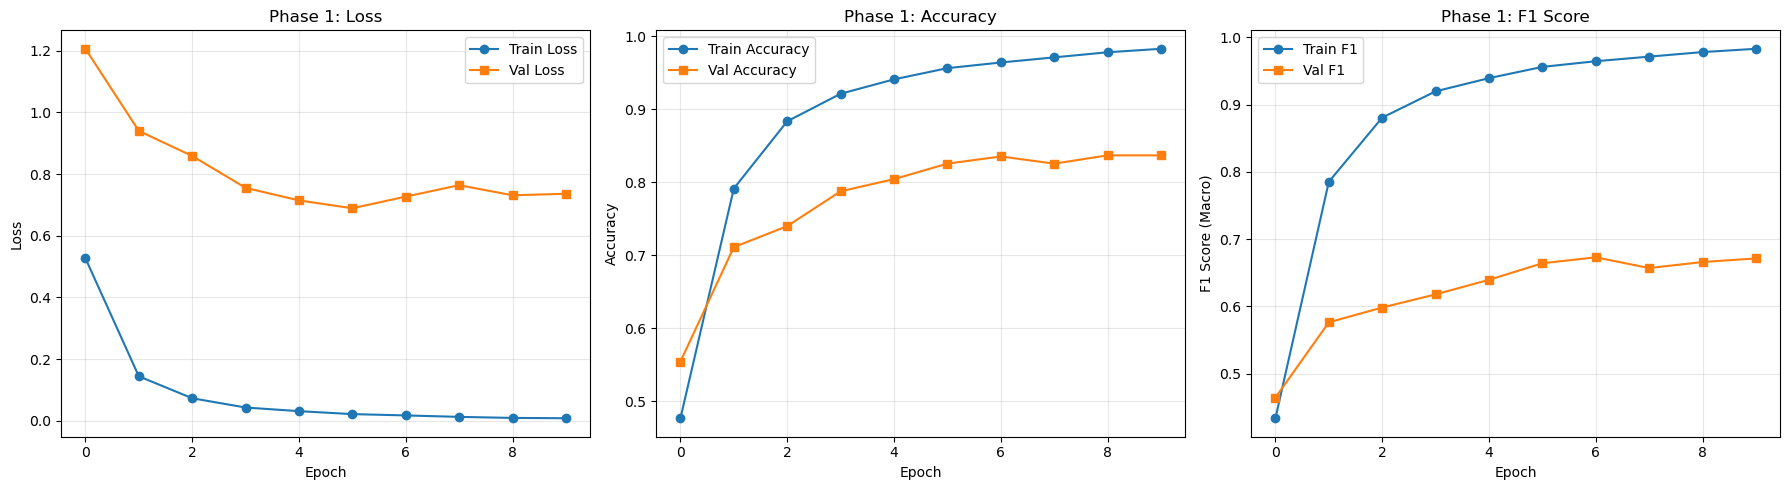

In [23]:
# Visualize Phase 1 training
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(phase1_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(phase1_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Phase 1: Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(phase1_history['train_accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(phase1_history['val_accuracy'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Phase 1: Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(phase1_history['train_f1'], label='Train F1', marker='o')
axes[2].plot(phase1_history['val_f1'], label='Val F1', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score (Macro)')
axes[2].set_title('Phase 1: F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Phase 2: Full Fine-Tuning

Unfreeze all layers and continue training with reduced learning rate

In [24]:
# Phase 2: Unfreeze all layers
print("="*80)
print("PHASE 2: Full Fine-Tuning")
print("="*80)

unfreeze_all_layers(model)

# Create data loaders for Phase 2 with weighted sampling
# Training loader uses weighted sampler for continued balanced training
train_loader_phase2 = DataLoader(
    train_dataset,
    batch_size=config.PHASE2_BATCH_SIZE,
    sampler=WeightedRandomSampler(  # Re-create sampler for Phase 2
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    ),
    num_workers=0,
    pin_memory=True
)

# Validation loader remains unchanged
val_loader_phase2 = DataLoader(
    val_dataset,
    batch_size=config.PHASE2_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"\nTrain batches: {len(train_loader_phase2)} (with weighted sampling)")
print(f"Validation batches: {len(val_loader_phase2)} (standard sampling)")

PHASE 2: Full Fine-Tuning
All layers unfrozen
Trainable parameters: 124,444,420 / 124,444,420 (100.00%)

Train batches: 330 (with weighted sampling)
Validation batches: 83 (standard sampling)


In [25]:
# Optimizer for Phase 2 (with lower learning rate)
optimizer_phase2 = AdamW(
    model.parameters(),
    lr=config.PHASE2_LR,  # Fresh start at lower learning rate
    weight_decay=config.WEIGHT_DECAY
)

# ============================================================================
# Phase 2 Learning Rate Schedule (Independent)
# ============================================================================
# Create a NEW scheduler for Phase 2 - starts fresh at PHASE2_LR and decays

total_steps_phase2 = len(train_loader_phase2) * config.PHASE2_EPOCHS
warmup_steps_phase2 = int(total_steps_phase2 * config.WARMUP_RATIO)

scheduler_phase2 = get_linear_schedule_with_warmup(
    optimizer_phase2,
    num_warmup_steps=warmup_steps_phase2,
    num_training_steps=total_steps_phase2  # Only Phase 2 steps
)

print(f"\nPhase 2 Training Configuration:")
print(f"Learning rate: {config.PHASE2_LR} (fresh start)")
print(f"Epochs: {config.PHASE2_EPOCHS}")
print(f"Batch size: {config.PHASE2_BATCH_SIZE}")
print(f"Total steps: {total_steps_phase2}")
print(f"Warmup steps: {warmup_steps_phase2}")


Phase 2 Training Configuration:
Learning rate: 1e-06 (fresh start)
Epochs: 5
Batch size: 16
Total steps: 1650
Warmup steps: 165


In [26]:
# Training loop for Phase 2 with early stopping
phase2_history = {
    'train_loss': [],
    'train_accuracy': [],
    'train_f1': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1': []
}

best_val_f1_phase2 = best_val_f1_phase1

# Initialize early stopping for Phase 2
early_stopping_phase2 = EarlyStopping(
    patience=config.EARLY_STOPPING_PATIENCE,
    min_delta=0.001,
    mode='max'
)

print(f"\nEarly stopping enabled with patience={config.EARLY_STOPPING_PATIENCE}")
print(f"Training will stop if validation F1 doesn't improve for {config.EARLY_STOPPING_PATIENCE} epochs\n")

for epoch in range(1, config.PHASE2_EPOCHS + 1):
    print(f"\n{'='*80}")
    print(f"Phase 2 - Epoch {epoch}/{config.PHASE2_EPOCHS}")
    print(f"{'='*80}")
    
    # Train with weighted loss function
    train_metrics = train_epoch(
        model=model,
        dataloader=train_loader_phase2,
        optimizer=optimizer_phase2,
        scheduler=scheduler_phase2,  # Use Phase 2's own scheduler
        device=config.DEVICE,
        epoch=epoch,
        loss_fn=weighted_loss_fn,  # Use weighted loss
        gradient_accumulation_steps=config.GRADIENT_ACCUMULATION_STEPS,
        max_grad_norm=config.MAX_GRAD_NORM
    )
    
    # Evaluate
    val_metrics = evaluate(
        model=model,
        dataloader=val_loader_phase2,
        device=config.DEVICE
    )
    
    # Store metrics
    phase2_history['train_loss'].append(train_metrics['loss'])
    phase2_history['train_accuracy'].append(train_metrics['accuracy'])
    phase2_history['train_f1'].append(train_metrics['f1_macro'])
    phase2_history['val_loss'].append(val_metrics['loss'])
    phase2_history['val_accuracy'].append(val_metrics['accuracy'])
    phase2_history['val_f1'].append(val_metrics['f1_macro'])
    
    # Print metrics (emphasize F1 score for imbalanced data)
    print(f"\nTrain Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1 (Macro): {train_metrics['f1_macro']:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1 (Macro): {val_metrics['f1_macro']:.4f}")
    
    # Save best model based on macro F1-score
    if val_metrics['f1_macro'] > best_val_f1_phase2:
        best_val_f1_phase2 = val_metrics['f1_macro']
        print(f"\n New best F1 score: {best_val_f1_phase2:.4f}")
        
        # Save checkpoint
        os.makedirs(config.OUTPUT_DIR, exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_phase2.state_dict(),
            'val_f1': best_val_f1_phase2,
        }, os.path.join(config.OUTPUT_DIR, 'best_model_phase2.pt'))
    
    # Early stopping check based on validation F1
    if early_stopping_phase2(val_metrics['f1_macro']):
        print(f"\nEarly stopping triggered! No improvement in validation F1 for {config.EARLY_STOPPING_PATIENCE} epochs")
        print(f"Stopping Phase 2 at epoch {epoch}")
        break

print(f"\n{'='*80}")
print(f"Phase 2 Complete!")
print(f"Best Validation F1 (Macro): {best_val_f1_phase2:.4f}")
print(f"{'='*80}")


Early stopping enabled with patience=5
Training will stop if validation F1 doesn't improve for 5 epochs


Phase 2 - Epoch 1/5


Epoch 1:   0%|          | 0/330 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]


Train Loss: 0.0089 | Train Acc: 0.9848 | Train F1 (Macro): 0.9847
Val Loss: 0.7638 | Val Acc: 0.8371 | Val F1 (Macro): 0.6709

Phase 2 - Epoch 2/5


Epoch 2:   0%|          | 0/330 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]


Train Loss: 0.0068 | Train Acc: 0.9862 | Train F1 (Macro): 0.9862
Val Loss: 0.7773 | Val Acc: 0.8394 | Val F1 (Macro): 0.6626

Phase 2 - Epoch 5/5


Epoch 5:   0%|          | 0/330 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]


Train Loss: 0.0058 | Train Acc: 0.9856 | Train F1 (Macro): 0.9855
Val Loss: 0.7798 | Val Acc: 0.8417 | Val F1 (Macro): 0.6657

Phase 2 Complete!
Best Validation F1 (Macro): 0.6730


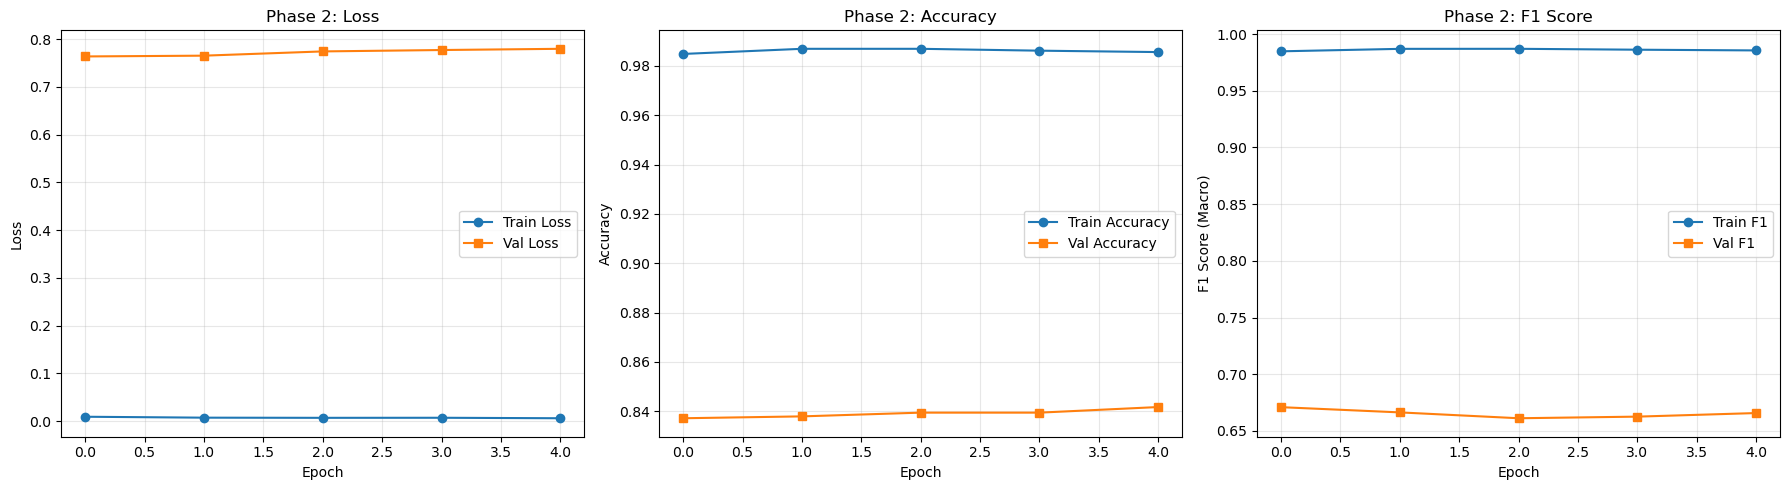

In [27]:
# Visualize Phase 2 training
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(phase2_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(phase2_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Phase 2: Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(phase2_history['train_accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(phase2_history['val_accuracy'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Phase 2: Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(phase2_history['train_f1'], label='Train F1', marker='o')
axes[2].plot(phase2_history['val_f1'], label='Val F1', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score (Macro)')
axes[2].set_title('Phase 2: F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

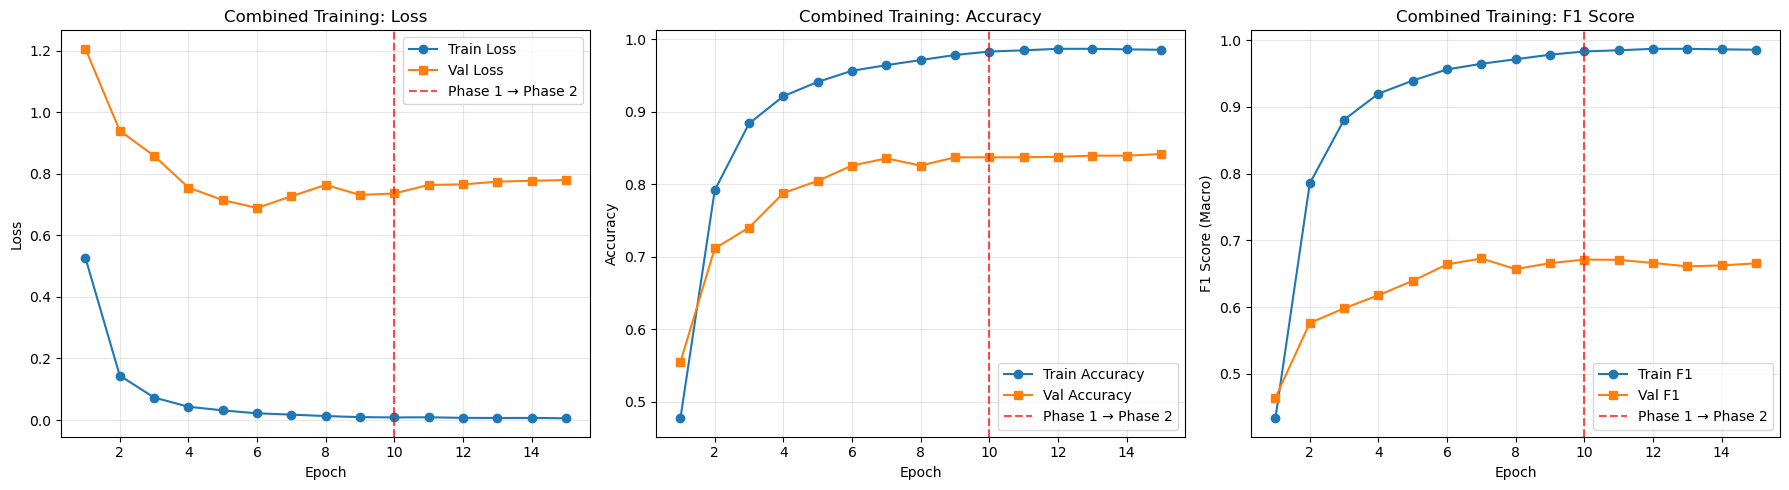

In [28]:
# Combined visualization of both phases
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Combine histories
combined_train_loss = phase1_history['train_loss'] + phase2_history['train_loss']
combined_val_loss = phase1_history['val_loss'] + phase2_history['val_loss']
combined_train_acc = phase1_history['train_accuracy'] + phase2_history['train_accuracy']
combined_val_acc = phase1_history['val_accuracy'] + phase2_history['val_accuracy']
combined_train_f1 = phase1_history['train_f1'] + phase2_history['train_f1']
combined_val_f1 = phase1_history['val_f1'] + phase2_history['val_f1']

epochs_range = list(range(1, len(combined_train_loss) + 1))
phase1_end = config.PHASE1_EPOCHS

# Loss
axes[0].plot(epochs_range, combined_train_loss, label='Train Loss', marker='o')
axes[0].plot(epochs_range, combined_val_loss, label='Val Loss', marker='s')
axes[0].axvline(x=phase1_end, color='r', linestyle='--', label='Phase 1 → Phase 2', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Combined Training: Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, combined_train_acc, label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, combined_val_acc, label='Val Accuracy', marker='s')
axes[1].axvline(x=phase1_end, color='r', linestyle='--', label='Phase 1 → Phase 2', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Combined Training: Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(epochs_range, combined_train_f1, label='Train F1', marker='o')
axes[2].plot(epochs_range, combined_val_f1, label='Val F1', marker='s')
axes[2].axvline(x=phase1_end, color='r', linestyle='--', label='Phase 1 → Phase 2', alpha=0.7)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score (Macro)')
axes[2].set_title('Combined Training: F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Final Evaluation

In [29]:
# Final evaluation on validation set
print("="*80)
print("FINAL EVALUATION")
print("="*80)

final_metrics = evaluate(
    model=model,
    dataloader=val_loader_phase2,
    device=config.DEVICE
)

print(f"\nFinal Validation Metrics:")
print(f"Loss: {final_metrics['loss']:.4f}")
print(f"Accuracy: {final_metrics['accuracy']:.4f}")
print(f"F1 Score (Macro): {final_metrics['f1_macro']:.4f}  ⭐ Primary metric for imbalanced data")

# Classification report with per-class metrics
print(f"\n{'='*80}")
print("Classification Report (Per-Class Metrics):")
print(f"{'='*80}")
class_names = ['Not_fake', 'fake', 'satire', 'not_news']
print(classification_report(
    final_metrics['labels'],
    final_metrics['predictions'],
    target_names=class_names,
    digits=4
))

FINAL EVALUATION


Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]


Final Validation Metrics:
Loss: 0.7798
Accuracy: 0.8417
F1 Score (Macro): 0.6657  ⭐ Primary metric for imbalanced data

Classification Report (Per-Class Metrics):
              precision    recall  f1-score   support

    Not_fake     0.9299    0.8876    0.9083       792
        fake     0.6867    0.7203    0.7031       143
      satire     0.3333    0.2174    0.2632        23
    not_news     0.7519    0.8287    0.7884       362

    accuracy                         0.8417      1320
   macro avg     0.6754    0.6635    0.6657      1320
weighted avg     0.8443    0.8417    0.8419      1320



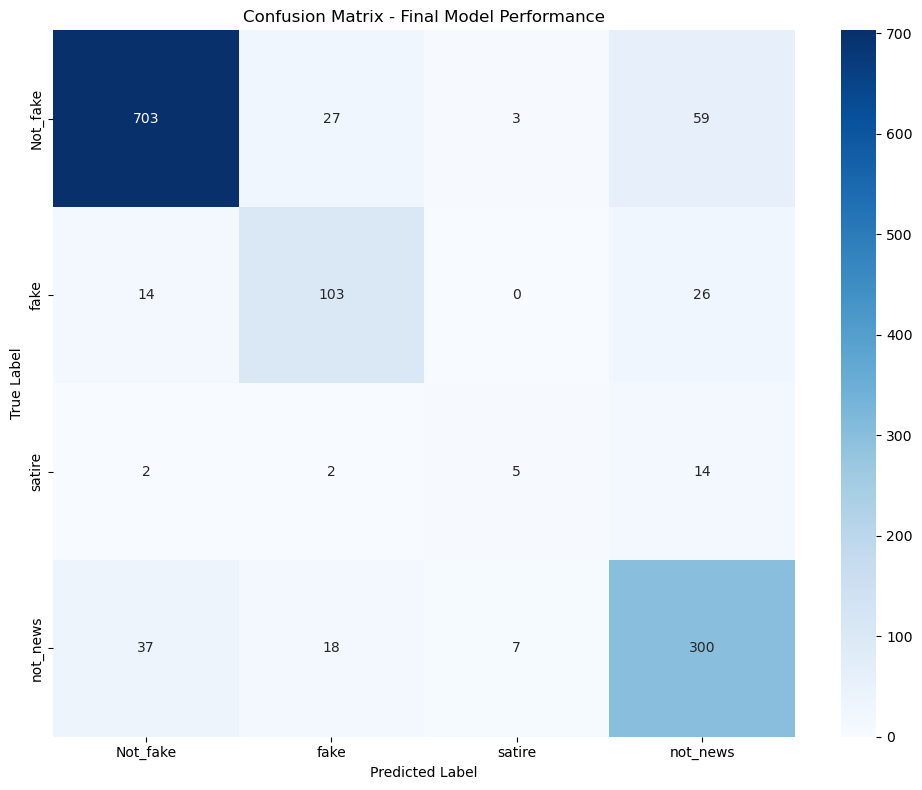

In [30]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

class_names = ['Not_fake', 'fake', 'satire', 'not_news']
cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Final Model Performance')
plt.tight_layout()
plt.show()

## 9. Save Final Model

In [31]:
# Save the final fine-tuned model and tokenizer
print("=" * 80)
print("SAVING MODEL")
print("=" * 80)

os.makedirs(config.MODEL_SAVE_PATH, exist_ok=True)

# Save model
model.save_pretrained(config.MODEL_SAVE_PATH)
print(f"Model saved to: {config.MODEL_SAVE_PATH}")

# Save tokenizer
tokenizer.save_pretrained(config.MODEL_SAVE_PATH)
print(f"Tokenizer saved to: {config.MODEL_SAVE_PATH}")

# Save training history
import json

history = {
    'phase1': phase1_history,
    'phase2': phase2_history,
    'best_val_f1_phase1': best_val_f1_phase1,
    'best_val_f1_phase2': best_val_f1_phase2,
    'final_metrics': {
        'loss': final_metrics['loss'],
        'accuracy': final_metrics['accuracy'],
        'f1_macro': final_metrics['f1_macro']
    }
}

with open(os.path.join(config.MODEL_SAVE_PATH, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved to: {config.MODEL_SAVE_PATH}/training_history.json")

SAVING MODEL
Model saved to: ./saved_model
Tokenizer saved to: ./saved_model
Training history saved to: ./saved_model/training_history.json


## 10. Inference

In [32]:
# How to load the best model checkpoint
print("\n" + "="*80)
print("LOADING BEST MODEL CHECKPOINT")
print("="*80)

# Load best checkpoint from Phase 2
best_checkpoint_path = os.path.join(config.OUTPUT_DIR, 'best_model_phase2.pt')

if os.path.exists(best_checkpoint_path):
    checkpoint = torch.load(best_checkpoint_path, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"\nLoaded best model checkpoint:")
    print(f"   Epoch: {checkpoint['epoch']}")
    print(f"   Validation F1 (Macro): {checkpoint['val_f1']:.4f}")
    print(f"\n   This model should be used for final evaluation and deployment.")
else:
    print(f"\nCheckpoint not found at {best_checkpoint_path}")
    print(f"   Using current model state (end of Phase 2)")

print("="*80)


LOADING BEST MODEL CHECKPOINT

Checkpoint not found at ./outputs/best_model_phase2.pt
   Using current model state (end of Phase 2)


In [33]:
# Inference function
def predict(text, model, tokenizer, device, max_length=256):
    """
    Predict the class of a given text
    """
    model.eval()
    
    # Tokenize
    encoding = tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()
    
    return {
        'predicted_class': pred_class,
        'confidence': confidence,
        'all_probabilities': probs[0].cpu().numpy()
    }



COMPREHENSIVE TEST SET EVALUATION
Evaluating model on 733 held-out test samples...

Test dataset size: 733
Test batches: 46



Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]

TEST SET RESULTS (FINAL MODEL PERFORMANCE)

Test Loss: 0.8436
Test Accuracy: 0.8049
Test F1 Score (Macro): 0.6837  PRIMARY METRIC

DETAILED CLASSIFICATION REPORT (TEST SET)

              precision    recall  f1-score   support

    Not_fake     0.9098    0.8477    0.8776       440
        fake     0.6173    0.6329    0.6250        79
      satire     0.4375    0.5385    0.4828        13
    not_news     0.7080    0.7960    0.7494       201

    accuracy                         0.8049       733
   macro avg     0.6681    0.7038    0.6837       733
weighted avg     0.8145    0.8049    0.8083       733



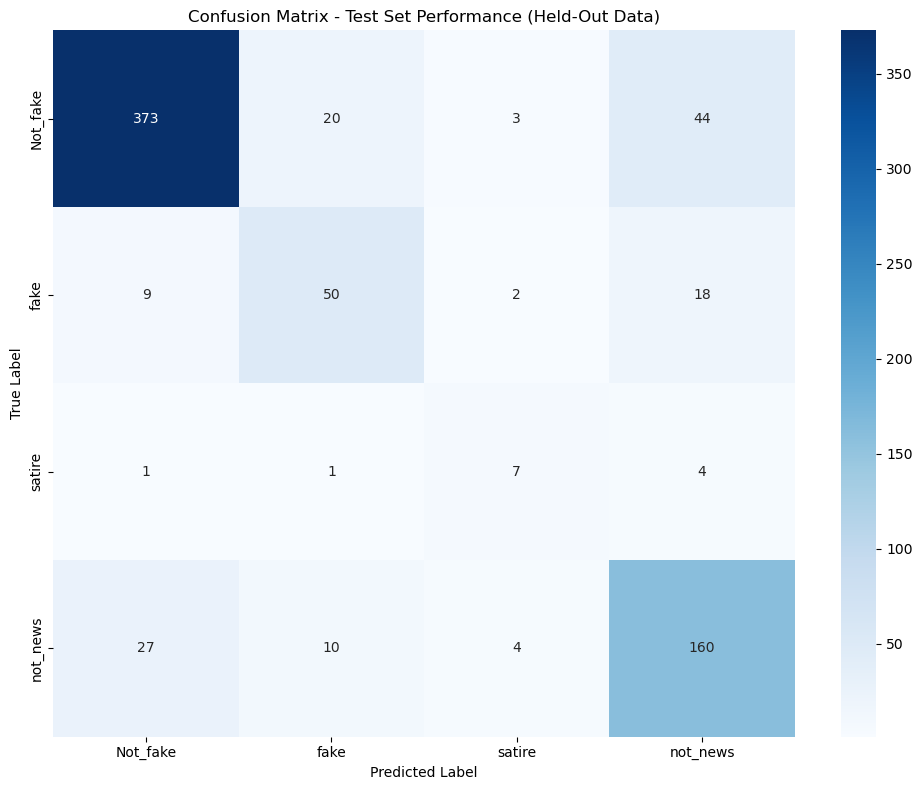


VALIDATION vs TEST PERFORMANCE COMPARISON

Metric               Validation      Test            Difference     
-----------------------------------------------------------------
Accuracy             0.8417          0.8049          -0.0368        
F1 Score (Macro)     0.6657          0.6837          +0.0180        
Loss                 0.7798          0.8436          +0.0638        

✅ Model generalizes well! Test and validation performance are similar.


In [34]:
# ============================================================================
# COMPREHENSIVE EVALUATION ON ENTIRE TEST SET
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE TEST SET EVALUATION")
print("="*80)
print(f"Evaluating model on {len(test_df)} held-out test samples...\n")

# Create test dataset and dataloader
test_dataset = FakeNewsDataset(
    texts=test_df['text'].values,
    labels=test_df['label'].values,
    tokenizer=tokenizer,
    max_length=config.MAX_LENGTH
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.PHASE2_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Test dataset size: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}\n")

# Evaluate on test set
test_metrics = evaluate(
    model=model,
    dataloader=test_loader,
    device=config.DEVICE
)

print("="*80)
print("TEST SET RESULTS (FINAL MODEL PERFORMANCE)")
print("="*80)
print(f"\nTest Loss: {test_metrics['loss']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test F1 Score (Macro): {test_metrics['f1_macro']:.4f}  PRIMARY METRIC")

# Per-class metrics
print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT (TEST SET)")
print(f"{'='*80}\n")
class_names = ['Not_fake', 'fake', 'satire', 'not_news']
print(classification_report(
    test_metrics['labels'],
    test_metrics['predictions'],
    target_names=class_names,
    digits=4
))

# Confusion matrix for test set
fig, ax = plt.subplots(figsize=(10, 8))

cm_test = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Test Set Performance (Held-Out Data)')
plt.tight_layout()
plt.show()

# Compare validation vs test performance
print("\n" + "="*80)
print("VALIDATION vs TEST PERFORMANCE COMPARISON")
print("="*80)
print(f"\n{'Metric':<20} {'Validation':<15} {'Test':<15} {'Difference':<15}")
print("-" * 65)
print(f"{'Accuracy':<20} {final_metrics['accuracy']:<15.4f} {test_metrics['accuracy']:<15.4f} {test_metrics['accuracy'] - final_metrics['accuracy']:<+15.4f}")
print(f"{'F1 Score (Macro)':<20} {final_metrics['f1_macro']:<15.4f} {test_metrics['f1_macro']:<15.4f} {test_metrics['f1_macro'] - final_metrics['f1_macro']:<+15.4f}")
print(f"{'Loss':<20} {final_metrics['loss']:<15.4f} {test_metrics['loss']:<15.4f} {test_metrics['loss'] - final_metrics['loss']:<+15.4f}")

print("\n" + "="*80)
if abs(test_metrics['f1_macro'] - final_metrics['f1_macro']) < 0.05:
    print("✅ Model generalizes well! Test and validation performance are similar.")
elif test_metrics['f1_macro'] < final_metrics['f1_macro'] - 0.05:
    print("⚠️  Possible overfitting: Test performance is notably lower than validation.")
else:
    print("✅ Test performance is good!")
print("="*80)